<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/RFM_segmentation(using_kmeans_clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/OnlineRetail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**InvoiceNo**

- A unique number assigned to each invoice or transaction.

- If a customer buys multiple products in a single transaction, all those products will have the same InvoiceNo, linking them together.

- Can be used to track transactions, calculate total sales per invoice, or find repeat purchases.

**StockCode**

- A unique code assigned to each product/item in the store.

- Helps to identify products programmatically.

- Multiple rows can have the same StockCode if the same product is bought in different invoices.

**Description**

- The textual name or description of the product.

- Useful for human-readable understanding, filtering products by name, or performing text-based analysis.

- It corresponds one-to-one with StockCode, but sometimes multiple StockCodes may have similar descriptions.

**Quantity**

- Number of units purchased of that specific product in that invoice.

- Can be negative if the product was returned.

- Used to calculate total items sold, total revenue per product, and stock movement.

**InvoiceDate**

- Date and time when the invoice was generated.

- Same for all products in a single invoice.

- Important for time-series analysis, seasonality, and sales trends.

**UnitPrice**

- Price per unit of the product in the currency of the dataset (e.g., GBP).

- Revenue for that line can be calculated as Quantity × UnitPrice.

- Useful for revenue analysis, pricing strategy, and discount evaluation.

**CustomerID**

- Unique ID assigned to each customer.

- Same for all products purchased by the same customer in a single invoice.

- Useful for customer-level analysis, segmentation, and loyalty analysis.

**Country**

- Country of the customer.

- Helps in geographic analysis, regional sales trends, and market segmentation.

For customer segmentation, we have to group customers based on their behavior, value, and preferences.There are common three factors to Group customers: <br>
**Recency**

- How recently a customer made a purchase.

- Can be Derived from InvoiceDate and the most recent date in  dataset.

- Will Help to identify active vs. inactive customers.

**Frequency**

- How often a customer buys.

- Can be calculated as the number of invoices or transactions per customer (InvoiceNo).

- Helps identify loyal vs. occasional customers.

**Monetary / Revenue**

- How much money a customer has spent.

- Calculated as Quantity × UnitPrice summed over all transactions per customer.

- Helps to identify high-value vs. low-value customers.


- **Monetary** : quantity * unite price
- **Recency**: last purchase date from InvoiceDate
- **Frequency:** Total Number of Invoices/Transaction from InvoiceNo

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# FInding Recency For all Customer"

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
last_invoiceDate= df['InvoiceDate'].max()
last_invoiceDate

Timestamp('2011-12-09 12:50:00')

In [8]:
referrence_or_currentDate = pd.to_datetime('2012-01-01')
referrence_or_currentDate

Timestamp('2012-01-01 00:00:00')

In [9]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [10]:
df['InvoiceDate']

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00
...,...
541904,2011-12-09 12:50:00
541905,2011-12-09 12:50:00
541906,2011-12-09 12:50:00
541907,2011-12-09 12:50:00


In [11]:
maxdate = df.groupby(['CustomerID'])[['InvoiceDate']].max()
maxdate

,InvoiceDate
CustomerID,
12346.0,2011-01-18 10:17:00
12347.0,2011-12-07 15:52:00
12348.0,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00
...,...
18280.0,2011-03-07 09:52:00
18281.0,2011-06-12 10:53:00
18282.0,2011-12-02 11:43:00


In [12]:
(referrence_or_currentDate - maxdate['InvoiceDate']).dt.days # this will show only days

,InvoiceDate
CustomerID,
12346.0,347
12347.0,24
12348.0,97
12349.0,40
12350.0,332
...,...
18280.0,299
18281.0,202
18282.0,29


# Recency Table

In [13]:
maxdate['InvoiceDays'] = (referrence_or_currentDate - maxdate['InvoiceDate']).dt.days
maxdate

,InvoiceDate,InvoiceDays
CustomerID,,
12346.0,2011-01-18 10:17:00,347
12347.0,2011-12-07 15:52:00,24
12348.0,2011-09-25 13:13:00,97
12349.0,2011-11-21 09:51:00,40
12350.0,2011-02-02 16:01:00,332
...,...,...
18280.0,2011-03-07 09:52:00,299
18281.0,2011-06-12 10:53:00,202
18282.0,2011-12-02 11:43:00,29


In [14]:
recency = maxdate.drop('InvoiceDate', axis=1)
recency.head()

,InvoiceDays
CustomerID,
12346.0,347
12347.0,24
12348.0,97
12349.0,40
12350.0,332


# Finding Frequency Value

For frequency calculation in customer segmentation, duplicate invoices should not be counted. Each invoice represents a single transaction, even if it contains multiple products. Counting all rows would inflate the frequency and give incorrect segmentation. Therefore, only distinct InvoiceNo per customer should be used to measure transaction frequency.

**Scenario:**

- Customer goes to the store once and buys 6 different products → all 6 rows share the same InvoiceNo.

- Next visit, buys another 6 products → new InvoiceNo is generated.

**Why we don’t count duplicates:**

- If you count all rows, each product row will be treated as a separate transaction → frequency will be inflated.

- Actual transaction frequency should count how many times the customer visited/purchased, not how many products they bought.

**Solution:**

- Use distinct InvoiceNo per CustomerID → each invoice counts as one transaction, regardless of how many products are in it.

In [15]:
df1 = df.copy()
freq = df1.drop_duplicates('InvoiceNo')
freq

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom
25,536369,21756,BATH BUILDING BLOCK WORD,3,2010-12-01 08:35:00,5.95,13047.0,United Kingdom
...,...,...,...,...,...,...,...,...
541865,581583,20725,LUNCH BAG RED RETROSPOT,40,2011-12-09 12:23:00,1.45,13777.0,United Kingdom
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom
541869,581585,22481,BLACK TEA TOWEL CLASSIC DESIGN,12,2011-12-09 12:31:00,0.39,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom


# Frequency Table

In [16]:
frequency = freq.groupby(['CustomerID'])[['InvoiceNo']].count()
frequency

,InvoiceNo
CustomerID,
12346.0,2
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,3


# Finding Monetory value

In [17]:
df['total'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


# Monetory Table

In [18]:
monetory = df.groupby(['CustomerID'])[['total']].sum()
monetory

,total
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,176.60


In [19]:
df[df['CustomerID'] == 12346.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6


In [20]:
monetory[monetory['total'] == 0]

,total
CustomerID,
12346.0,0.0
13256.0,0.0
13364.0,0.0
14557.0,0.0
14792.0,0.0
16742.0,0.0
16878.0,0.0
18268.0,0.0


In [21]:
monetory[monetory['total'] == 0].count()

,0
total,8


# RFM Table

In [22]:
RFM = pd.concat([recency,frequency, monetory], axis=1)
RFM

,InvoiceDays,InvoiceNo,total
CustomerID,,,
12346.0,347,2,0.00
12347.0,24,7,4310.00
12348.0,97,4,1797.24
12349.0,40,1,1757.55
12350.0,332,1,334.40
...,...,...,...
18280.0,299,1,180.60
18281.0,202,1,80.82
18282.0,29,3,176.60


In [23]:
RFM.columns = ['Recency','Frequency','Monetary']
RFM

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,347,2,0.00
12347.0,24,7,4310.00
12348.0,97,4,1797.24
12349.0,40,1,1757.55
12350.0,332,1,334.40
...,...,...,...
18280.0,299,1,180.60
18281.0,202,1,80.82
18282.0,29,3,176.60


# Scalling (Standard scaler)

In [24]:
# Scalling whole dataset
scalling_obj = StandardScaler()
scalled_data = scalling_obj.fit_transform(RFM)
scalled_data

array([[ 2.31656788, -0.32936215, -0.23100099],
       [-0.88904975,  0.20610242,  0.29343167],
       [-0.16456032, -0.11517632, -0.01231622],
       ...,
       [-0.83942719, -0.22226923, -0.20951263],
       [-0.87912524,  1.16993863,  0.02390005],
       [-0.49206924, -0.22226923, -0.00744423]])

In [25]:
scalled_data.shape

(4372, 3)

# Elbow Method (To find optimal K value)

**x axis-> some of square error<br>
y axis -> no of cluster**

## manual process

In [27]:
sum_of_square_error = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(scalled_data)
  sum_of_square_error.append(kmeans.inertia_)
sum_of_square_error

[13116.000000000004,
 9424.354643554996,
 6074.281828139145,
 4046.639585692468,
 3025.8028196063497,
 2383.6300441369035,
 1906.2798435315951,
 1684.3074599302224,
 1427.7592118367659,
 1252.4153080972415]

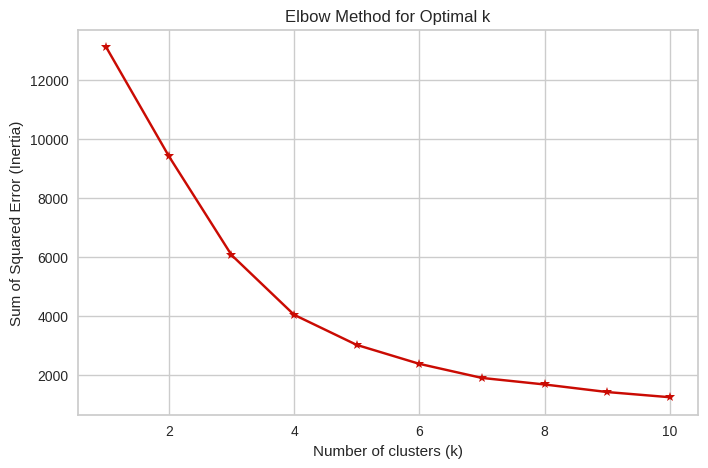

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), sum_of_square_error, 'r-*')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Error (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

## using library

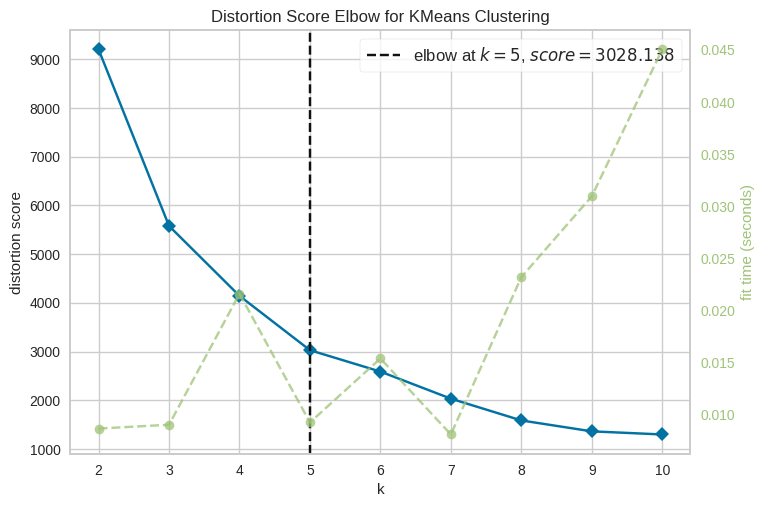

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
elbow  = KElbowVisualizer(KMeans(), k=10)
elbow.fit(scalled_data)
elbow.show()

# Model Creation

In [30]:
model = KMeans(n_clusters= 5)
model.fit(scalled_data)

KMeans(n_clusters=5)

In [31]:
model.labels_

array([4, 0, 0, ..., 0, 0, 0], dtype=int32)

In [32]:
RFM['Cluster'] = model.labels_
RFM

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,347,2,0.00,4
12347.0,24,7,4310.00,0
12348.0,97,4,1797.24,0
12349.0,40,1,1757.55,0
12350.0,332,1,334.40,4
...,...,...,...,...
18280.0,299,1,180.60,4
18281.0,202,1,80.82,1
18282.0,29,3,176.60,0


In [33]:
RFM['Cluster'].unique()

array([4, 0, 1, 2, 3], dtype=int32)

In [34]:
RFM[RFM['Cluster']== 0]

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,24,7,4310.00,0
12348.0,97,4,1797.24,0
12349.0,40,1,1757.55,0
12352.0,58,11,1545.41,0
12356.0,44,3,2811.43,0
...,...,...,...,...
18276.0,43,3,323.36,0
18277.0,80,2,97.63,0
18282.0,29,3,176.60,0


In [35]:
RFM[RFM['Cluster']== 1]

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12353.0,226,1,89.00,1
12363.0,131,2,552.00,1
12378.0,151,1,4008.62,1
12379.0,103,3,850.29,1
12383.0,206,6,1839.31,1
...,...,...,...,...
18260.0,194,8,2595.00,1
18262.0,162,1,149.48,1
18268.0,156,2,0.00,1


In [36]:
RFM[RFM['Cluster']== 2]

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12415.0,46,26,123725.45,2
14156.0,31,66,113384.14,2
14646.0,23,77,279489.02,2
14911.0,23,248,132572.62,2
17450.0,30,55,187482.17,2
18102.0,22,62,256438.49,2


In [37]:
RFM[RFM['Cluster']== 3]

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12471.0,24,49,18740.92,3
12569.0,24,35,4064.99,3
12682.0,25,31,12288.22,3
12748.0,22,224,29072.10,3
12901.0,30,36,16293.10,3
...,...,...,...,...
17811.0,26,51,7677.71,3
17841.0,23,169,40340.78,3
17857.0,25,25,26763.34,3


In [38]:
RFM[RFM['Cluster']== 4]

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,347,2,0.00,4
12350.0,332,1,334.40,4
12354.0,254,1,1079.40,4
12355.0,236,1,459.40,4
12361.0,309,1,189.90,4
...,...,...,...,...
18239.0,240,5,1561.61,4
18250.0,323,2,342.92,4
18256.0,376,1,-50.10,4


In [39]:
RFM[RFM['Cluster']== 5]

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,


In [40]:
final_result = RFM.groupby(['Cluster'])[['Recency',	'Frequency',	'Monetary']].mean()
final_result

,Recency,Frequency,Monetary
Cluster,,,
0,50.320713,5.622866,1729.330788
1,158.281385,2.389610,696.320532
2,29.166667,89.000000,182181.981667
3,26.718750,50.328125,25455.760156
4,311.222222,1.577485,402.906374


In [41]:
segment_map = {
    0: "Lost Customers",        # High Recency, Low Frequency, Low Monetary
    1: "At Risk",               # Medium Recency, Low Frequency, Medium Monetary
    2: "Champions",             # Very recent, very frequent, highest value
    3: "Loyal Customers",       # Very recent, very frequent, high spend
    4: "Potential Loyalists"    # Recent, moderate frequency and spend
}
RFM['Segment'] = RFM['Cluster'].map(segment_map)


RFM[['Recency','Frequency','Monetary','Cluster','Segment']]

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,347,2,0.00,4,Potential Loyalists
12347.0,24,7,4310.00,0,Lost Customers
12348.0,97,4,1797.24,0,Lost Customers
12349.0,40,1,1757.55,0,Lost Customers
12350.0,332,1,334.40,4,Potential Loyalists
...,...,...,...,...,...
18280.0,299,1,180.60,4,Potential Loyalists
18281.0,202,1,80.82,1,At Risk
18282.0,29,3,176.60,0,Lost Customers


In [42]:
result = RFM[['Recency','Frequency','Monetary','Cluster','Segment']]
result

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,347,2,0.00,4,Potential Loyalists
12347.0,24,7,4310.00,0,Lost Customers
12348.0,97,4,1797.24,0,Lost Customers
12349.0,40,1,1757.55,0,Lost Customers
12350.0,332,1,334.40,4,Potential Loyalists
...,...,...,...,...,...
18280.0,299,1,180.60,4,Potential Loyalists
18281.0,202,1,80.82,1,At Risk
18282.0,29,3,176.60,0,Lost Customers


In [43]:
segment_counts = result.groupby(['Segment']).size().reset_index(name='Number of Customers')
segment_counts

,Segment,Number of Customers
0,At Risk,924
1,Champions,6
2,Lost Customers,2694
3,Loyal Customers,64
4,Potential Loyalists,684


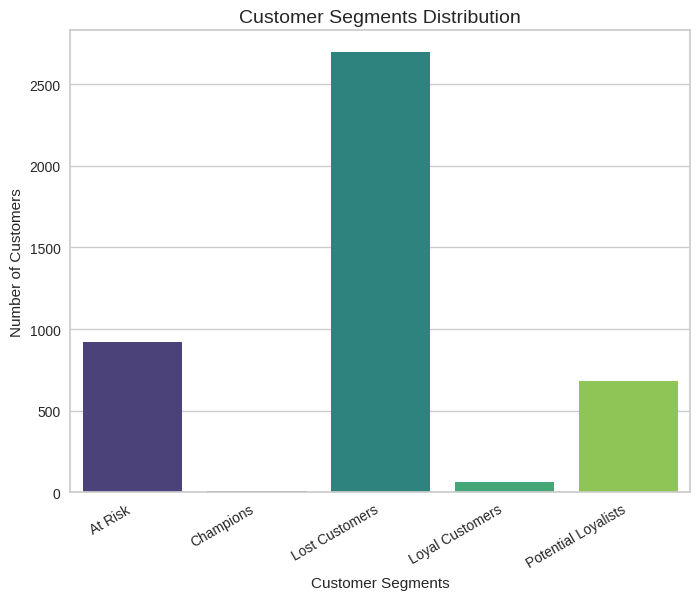

In [44]:
plt.figure(figsize=(8,6))
sns.barplot(x='Segment', y='Number of Customers', data=segment_counts, palette="viridis")

plt.title("Customer Segments Distribution", fontsize=14)
plt.xlabel("Customer Segments")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")  # rotate labels for readability
plt.show()